In [ ]:
#1. Handling Missing Values and Scaling Techniques

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Feature Engineering
from sklearn.ensemble import IsolationForest

In [3]:
# Load dataset
df = pd.read_csv("C:/Users/Harshitha/Downloads/Data Trasformation/adult_with_headers (1).csv")

# Display first 5 rows
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (32561, 15)


In [5]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [8]:
df.replace(" ?", np.nan, inplace=True)

In [9]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy='mean')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

In [11]:
cat_cols = df.select_dtypes(include=['object']).columns

cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [12]:
numerical_features = ['age', 'fnlwgt', 'education_num',
                      'capital_gain', 'capital_loss',
                      'hours_per_week']

In [13]:
standard_scaler = StandardScaler()

df_standard_scaled = df.copy()

df_standard_scaled[numerical_features] = standard_scaler.fit_transform(
    df_standard_scaled[numerical_features]
)

df_standard_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


In [14]:
minmax_scaler = MinMaxScaler()

df_minmax_scaled = df.copy()

df_minmax_scaled[numerical_features] = minmax_scaler.fit_transform(
    df_minmax_scaled[numerical_features]
)

df_minmax_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


In [ ]:
When is Min-Max Scaling Preferred?

Preferred Scenarios:
    
Data does not follow normal distribution
Neural Networks and Deep Learning models
When values must stay within a fixed range

Common Applications

Image Processing
Neural Networks
Gradient Descent Optimization
Why means min-max scaling preserves the original distribution while keeping all values between 0 and 1.

In [ ]:
#2. Encoding Techniques and Data Exploration

In [17]:
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [18]:
small_cat_cols = [col for col in categorical_cols
                  if df[col].nunique() < 5]

print("Columns with less than 5 categories:")
print(small_cat_cols)

Columns with less than 5 categories:
['sex', 'income']


In [19]:
df_onehot = pd.get_dummies(df,columns=small_cat_cols, drop_first=True)
df_onehot.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Male,income_ >50K
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,2174.0,0.0,40.0,United-States,True,False
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,0.0,0.0,13.0,United-States,True,False
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,0.0,0.0,40.0,United-States,True,False
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,0.0,0.0,40.0,United-States,True,False
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,0.0,0.0,40.0,Cuba,False,False


In [20]:
#Label Encoding
large_cat_cols = [col for col in categorical_cols
                  if df[col].nunique() >= 5]

print("Columns with more than 5 categories:")
print(large_cat_cols)

Columns with more than 5 categories:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']


In [21]:
label_encoders = {}

for col in large_cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [22]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,6,77516.0,9,13.0,4,0,1,4,Male,2174.0,0.0,40.0,38,<=50K
1,50.0,5,83311.0,9,13.0,2,3,0,4,Male,0.0,0.0,13.0,38,<=50K
2,38.0,3,215646.0,11,9.0,0,5,1,4,Male,0.0,0.0,40.0,38,<=50K
3,53.0,3,234721.0,1,7.0,2,5,0,2,Male,0.0,0.0,40.0,38,<=50K
4,28.0,3,338409.0,9,13.0,2,9,5,2,Female,0.0,0.0,40.0,4,<=50K


In [ ]:
Pros and Cons of One-Hot Encoding

Advantages
No ordinal relationship is introduced
Works well for nominal categorical data
Improves performance in many ML algorithms

Disadvantages
Increases dimensionality
Creates sparse datasets
Can increase memory usage

In [ ]:
Pros and Cons of Label Encoding

Advantages
Easy to implement
Memory efficient
Suitable for tree-based algorithms

Disadvantages
Introduces ordinal relationship
Some ML algorithms may misinterpret encoded values

In [24]:
#Feature Engineering
df['capital_difference'] = df['capital_gain'] - df['capital_loss']

In [25]:
df[['capital_gain',
    'capital_loss',
    'capital_difference']].head()

,capital_gain,capital_loss,capital_difference
0,2174.0,0.0,2174.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [26]:
df['hours_per_age'] = df['hours_per_week'] / df['age']

In [27]:
df[['age',
    'hours_per_week',
    'hours_per_age']].head()

,age,hours_per_week,hours_per_age
0,39.0,40.0,1.025641
1,50.0,13.0,0.260000
2,38.0,40.0,1.052632
3,53.0,40.0,0.754717
4,28.0,40.0,1.428571


In [28]:
numerical_cols = ['age',
                  'fnlwgt',
                  'education_num',
                  'capital_gain',
                  'capital_loss',
                  'hours_per_week']

print(df[numerical_cols].skew())

age                0.558743
fnlwgt             1.446980
education_num     -0.311676
capital_gain      11.953848
capital_loss       4.594629
hours_per_week     0.227643
dtype: float64


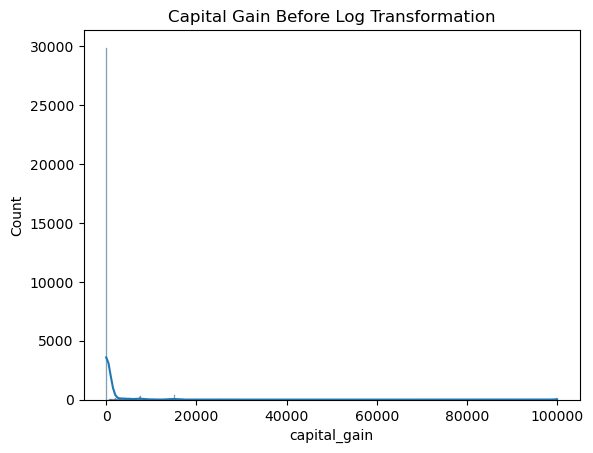

In [29]:
sns.histplot(df['capital_gain'], kde=True)

plt.title("Capital Gain Before Log Transformation")

plt.show()

In [30]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

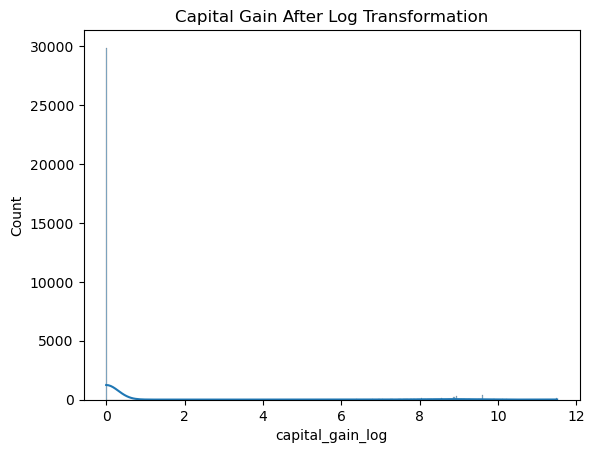

In [31]:
sns.histplot(df['capital_gain_log'], kde=True)

plt.title("Capital Gain After Log Transformation")

plt.show()

In [ ]:
Why Log Transformation?
Justification
capital_gain contains very large values and many zeros.
The distribution is highly right-skewed.
Log transformation:
Reduces skewness
Compresses large values
Makes distribution closer to normal
Improves machine learning model performance

In [32]:
print("Before Transformation:",
      df['capital_gain'].skew())

print("After Transformation:",
      df['capital_gain_log'].skew())

Before Transformation: 11.953847687699804
After Transformation: 3.096143524467517


In [33]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_difference,hours_per_age,capital_gain_log
0,39.0,6,77516.0,9,13.0,4,0,1,4,Male,2174.0,0.0,40.0,38,<=50K,2174.0,1.025641,7.684784
1,50.0,5,83311.0,9,13.0,2,3,0,4,Male,0.0,0.0,13.0,38,<=50K,0.0,0.260000,0.000000
2,38.0,3,215646.0,11,9.0,0,5,1,4,Male,0.0,0.0,40.0,38,<=50K,0.0,1.052632,0.000000
3,53.0,3,234721.0,1,7.0,2,5,0,2,Male,0.0,0.0,40.0,38,<=50K,0.0,0.754717,0.000000
4,28.0,3,338409.0,9,13.0,2,9,5,2,Female,0.0,0.0,40.0,4,<=50K,0.0,1.428571,0.000000


In [ ]:
onclusion

In this task:
Two new features were created:
capital_difference
hours_per_age
These features were created to capture:

Net financial status
Work intensity patterns
Log transformation was applied to the highly skewed capital_gain feature.
The transformation reduced skewness and improved the feature distribution for machine learning models.